# RESTOPS · Evaluate a four-week demand planning forecast

In [1]:
from pathlib import Path
import json
import os
import sys

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache/matplotlib"))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from src.common import read, TABLEAU, REPORTS
from src.reporting import style
style()
pd.set_option("display.max_columns", 12)


**Business question:** What daily sales should managers expect over the next 28 days?

Compare seasonal naive, calendar ridge and gradient boosting. Select by three rolling validation folds, then report a separate final-month holdout. Future lag values are recursive predictions.

In [2]:
metrics = pd.read_csv(REPORTS / "exports/forecast_metrics.csv")
metrics[metrics.evaluation_period.eq("Validation")].groupby("model")[["mae", "rmse", "mape", "wape"]].mean().sort_values("mae")

,mae,rmse,mape,wape
model,,,,
Calendar ridge,418.339942,525.395056,15.112709,14.142509
Gradient boosting,436.023741,549.613548,15.418550,14.739342
Seasonal naive,590.540007,750.295624,20.855471,19.900452


In [3]:
metrics[metrics.evaluation_period.eq("Holdout")][["model", "mae", "rmse", "mape", "wape", "interval_coverage"]]

,model,mae,rmse,mape,wape,interval_coverage
9,Seasonal naive,611.763353,783.511612,19.568895,18.879699,NaN
10,Calendar ridge,451.898682,586.967148,14.721121,13.946097,0.769841
11,Gradient boosting,470.820296,611.989742,14.918128,14.530039,NaN


In [4]:
summary = json.loads((REPORTS / "forecast_summary.json").read_text())
pd.Series(summary)

selected_model                                         Calendar ridge
selection_metric    Mean validation MAE across three rolling 28-da...
holdout_start                                              2025-12-04
holdout_end                                                2025-12-31
future_start                                               2026-01-01
future_end                                                 2026-01-28
forecast_total                                             1640024.16
interval_method     Per-store 80th percentile absolute validation ...
dtype: object

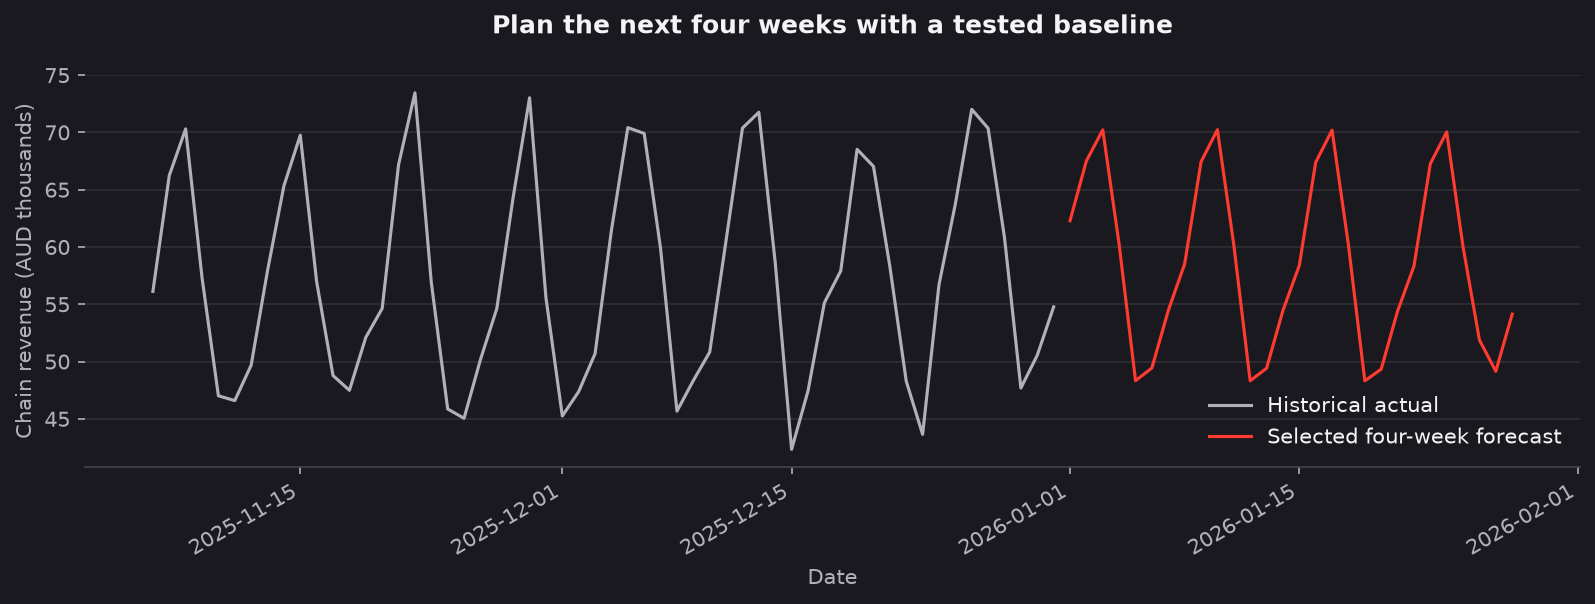

In [5]:
display(Image(filename=str(REPORTS / "figures/forecast.png")))

In [6]:
future = read("forecast_daily", TABLEAU)
future.groupby("restaurant_name").forecast_revenue.sum().sort_values(ascending=False).head(8)

restaurant_name
Chermside            104203.590067
Chadstone            103061.865483
Melbourne Central    102989.775484
Sydney Central       100044.749827
Parramatta            99777.700187
Brisbane Central      97619.769304
Chatswood             97183.163632
Gold Coast            95443.212694
Name: forecast_revenue, dtype: float64

In [7]:
future[["restaurant_name", "business_date", "forecast_revenue", "lower_80", "upper_80", "horizon_day"]].head(8)

,restaurant_name,business_date,forecast_revenue,lower_80,upper_80,horizon_day
0,Sydney Central,2026-01-01,3946.877828,3235.363611,4658.392045,1
1,Parramatta,2026-01-01,3721.090705,3040.309135,4401.872275,1
2,Bondi,2026-01-01,3307.991561,2777.061285,3838.921838,1
3,Newcastle,2026-01-01,3097.549503,2416.560970,3778.538036,1
4,Chatswood,2026-01-01,3601.384017,2795.095017,4407.673017,1
5,Wollongong,2026-01-01,2834.848459,2307.164276,3362.532642,1
6,Melbourne Central,2026-01-01,4127.807598,3374.692287,4880.922909,1
7,Richmond,2026-01-01,3477.349680,2933.670385,4021.028974,1


**Decision:** Use store forecasts with hourly demand mix to discuss labour and preparation, while monitoring error and recording overrides. Empirical store bands are approximate, and must not be summed into a chain interval. January 2026 is a synthetic continuation of this historical case study.